In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import pandas as pd
from PIL import Image
import cv2
from packaging import version

# Проверка версии torchvision
torchvision_version = version.parse(torchvision.__version__)
USE_NEW_WEIGHTS = False


SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
print(f"Seed fixed to: {SEED}")

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create directories for artifacts
os.makedirs("artifacts/figures", exist_ok=True)

Seed fixed to: 42
Using device: cpu


Train size: 40000, Val size: 10000, Test size: 10000
Train batches: 313, Val batches: 79
Batch x.shape: torch.Size([128, 3, 32, 32]), y.shape: torch.Size([128])


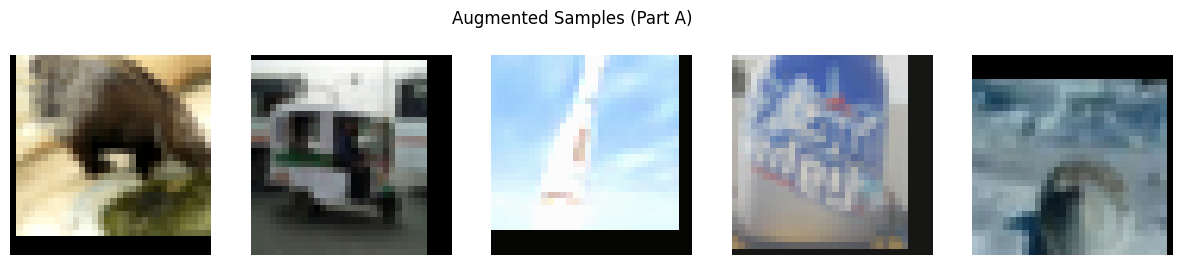

In [2]:
import ssl

ssl._create_default_https_context = ssl._create_unverified_context


full_train_dataset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transforms.ToTensor())

# Split indices with fixed seed (already set above)
num_train = len(full_train_dataset)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(0.8 * num_train))
train_indices, val_indices = indices[:split], indices[split:]

print(f"Train size: {len(train_indices)}, Val size: {len(val_indices)}, Test size: {len(test_dataset)}")

# Transforms for SimpleCNN (CIFAR normalization)
cifar_mean = (0.5071, 0.4867, 0.4435)
cifar_std = (0.2675, 0.2585, 0.2767)

transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std)
])

transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std)
])

# Custom Dataset Wrapper
class CIFAR100Split(torch.utils.data.Dataset):
    def __init__(self, root, train_indices, val_indices, transform_train, transform_val, train=True):
        self.full_data = torchvision.datasets.CIFAR100(root=root, train=True, download=True)
        self.indices = train_indices if train else val_indices
        self.transform = transform_train if train else transform_val

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, target = self.full_data[real_idx]
        if self.transform:
            img = self.transform(img)
        return img, target

# Initialize datasets
train_dataset = CIFAR100Split('./data', train_indices, val_indices, transform_aug, transform_base, train=True)
val_dataset = CIFAR100Split('./data', train_indices, val_indices, transform_aug, transform_base, train=False)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# Sanity Check Part A
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")
images, labels = next(iter(train_loader))
print(f"Batch x.shape: {images.shape}, y.shape: {labels.shape}")

# Visualize Augmentations
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    img, _ = train_dataset[i]
    img_np = img.permute(1, 2, 0).numpy() * np.array(cifar_std) + np.array(cifar_mean)
    ax.imshow(np.clip(img_np, 0, 1))
    ax.axis('off')
plt.suptitle("Augmented Samples (Part A)")
plt.savefig("artifacts/figures/augmentations_preview.png")
plt.show()

In [3]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    return total_loss / total, 100. * correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            total_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    return total_loss / total, 100. * correct / total


Running C1...
Epoch 2: Train Acc 32.30, Val Acc 34.27
Epoch 4: Train Acc 46.68, Val Acc 39.31
Epoch 6: Train Acc 57.31, Val Acc 40.75
Epoch 8: Train Acc 67.17, Val Acc 40.55
Epoch 10: Train Acc 75.07, Val Acc 39.31

Running C2...
Epoch 2: Train Acc 22.59, Val Acc 28.71
Epoch 4: Train Acc 31.95, Val Acc 35.56
Epoch 6: Train Acc 37.47, Val Acc 39.47
Epoch 8: Train Acc 41.45, Val Acc 42.14
Epoch 10: Train Acc 44.12, Val Acc 42.58

Running C3...


/Users/soldatov_a/Library/Python/3.11/lib/python/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/soldatov_a/Library/Python/3.11/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 2: Train Acc 24.95, Val Acc 24.15
Epoch 4: Train Acc 28.89, Val Acc 25.67
Epoch 6: Train Acc 30.34, Val Acc 25.38
Epoch 8: Train Acc 31.13, Val Acc 25.82
Epoch 10: Train Acc 31.83, Val Acc 25.93

Running C4...
Epoch 2: Train Acc 33.84, Val Acc 35.68
Epoch 4: Train Acc 40.07, Val Acc 39.35
Epoch 6: Train Acc 43.67, Val Acc 40.25
Epoch 8: Train Acc 46.69, Val Acc 41.37
Epoch 10: Train Acc 48.88, Val Acc 41.94
Saved best config: {'exp_id': 'C2', 'dataset': 'CIFAR100', 'seed': 42, 'model': 'SimpleCNN', 'lr': 0.001, 'epochs': 10, 'batch_size': 128, 'optimizer': 'Adam', 'criterion': 'CrossEntropyLoss', 'train_size': 40000, 'val_size': 10000, 'transforms': 'augmented'}


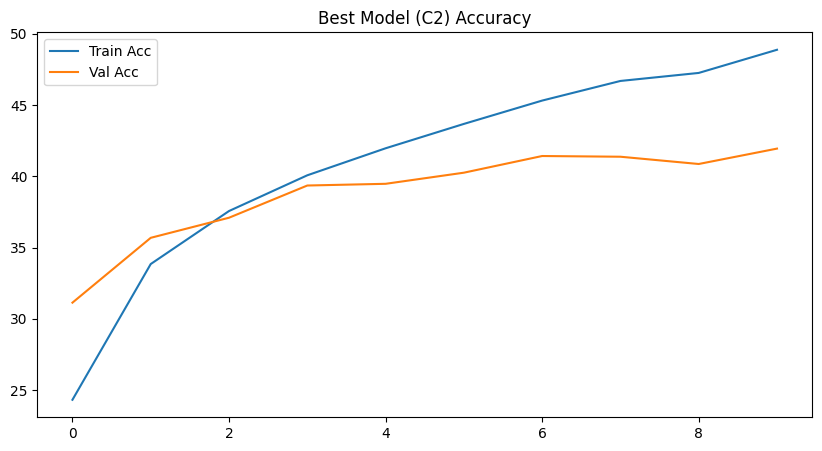

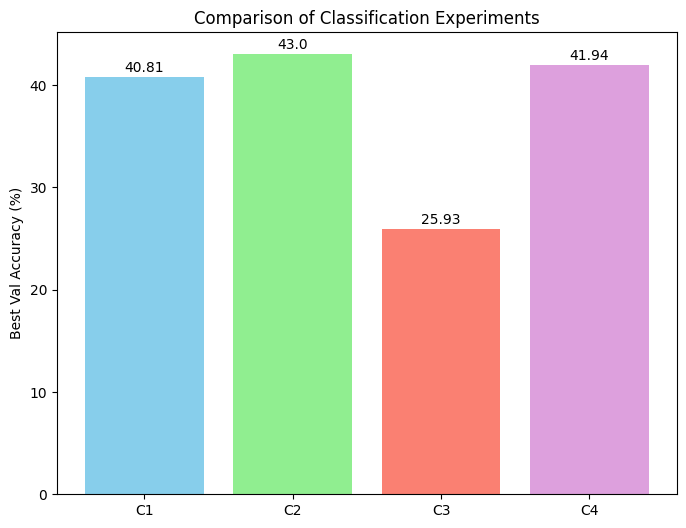

In [4]:
results = []

best_val_acc = -1
best_model_state = None
best_config = {}
best_test_accuracy = 0  # FIX: Сохраняем test_accuracy лучшей модели

# Common Hyperparams
epochs = 10
lr = 0.001
criterion = nn.CrossEntropyLoss()


class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Linear(128 * 4 * 4, 100)
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

def run_experiment(exp_id, model_class, use_aug=False, is_resnet=False, fine_tune=False, notes=""):
    global best_val_acc, best_model_state, best_config, best_test_accuracy

    print(f"\nRunning {exp_id}...")

    if is_resnet:
        # FIX: Используем weights.transforms() для pretrained ResNet
        if USE_NEW_WEIGHTS:
            weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1
            trans_im = weights.transforms()
            trans_im_aug = transforms.Compose([
                transforms.RandomHorizontalFlip(),
                transforms.RandomCrop(32, padding=4),
                weights.transforms()
            ])
        else:
            imb_mean, imb_std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
            trans_im = transforms.Compose([transforms.ToTensor(), transforms.Normalize(imb_mean, imb_std)])
            trans_im_aug = transforms.Compose([
                transforms.RandomHorizontalFlip(),
                transforms.RandomCrop(32, padding=4),
                transforms.ToTensor(),
                transforms.Normalize(imb_mean, imb_std)
            ])
        train_tf = trans_im_aug if use_aug else trans_im
        val_tf = trans_im
    else:
        train_tf = transform_aug if use_aug else transform_base
        val_tf = transform_base

    # Re-init datasets with specific transforms
    curr_train_ds = CIFAR100Split('./data', train_indices, val_indices, train_tf, val_tf, train=True)
    curr_val_ds = CIFAR100Split('./data', train_indices, val_indices, train_tf, val_tf, train=False)

    curr_train_loader = DataLoader(curr_train_ds, batch_size=128, shuffle=True, num_workers=0)
    curr_val_loader = DataLoader(curr_val_ds, batch_size=128, shuffle=False, num_workers=0)

    model = model_class().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        t_loss, t_acc = train_one_epoch(model, curr_train_loader, optimizer, criterion, device)
        v_loss, v_acc = evaluate(model, curr_val_loader, criterion, device)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        if (epoch+1) % 2 == 0:
            print(f"Epoch {epoch+1}: Train Acc {t_acc:.2f}, Val Acc {v_acc:.2f}")

    # Final Test Eval
    if is_resnet:
        if USE_NEW_WEIGHTS:
            weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1
            test_trans = weights.transforms()
        else:
            imb_mean, imb_std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
            test_trans = transforms.Compose([transforms.ToTensor(), transforms.Normalize(imb_mean, imb_std)])
        temp_test_ds = torchvision.datasets.CIFAR100(root='./data', train=False, transform=test_trans)
        temp_test_loader = DataLoader(temp_test_ds, batch_size=128, shuffle=False, num_workers=0)
        _, test_acc = evaluate(model, temp_test_loader, criterion, device)
    else:
        _, test_acc = evaluate(model, test_loader, criterion, device)

    best_v_acc = max(history['val_acc'])

    # Save best model globally
    if best_v_acc > best_val_acc:
        best_val_acc = best_v_acc
        best_model_state = model.state_dict()
        best_test_accuracy = test_acc  # FIX: Сохраняем test accuracy лучшей модели
        best_config = {
            "exp_id": exp_id,
            "dataset": "CIFAR100",
            "seed": SEED,
            "model": str(type(model).__name__),
            # FIX: Добавляем ключевые гиперпараметры
            "lr": lr,
            "epochs": epochs,
            "batch_size": batch_size,
            "optimizer": "Adam",
            "criterion": "CrossEntropyLoss",
            "train_size": len(train_indices),
            "val_size": len(val_indices),
            "transforms": "augmented" if use_aug else "base"
        }

    results.append({
        "experiment_id": exp_id,
        "task": "classification",
        "dataset": "CIFAR100",
        "seed": SEED,
        "model_summary": str(type(model).__name__),
        "optimizer": "Adam",
        "lr": lr,
        "epochs_trained": epochs,
        "best_val_accuracy": round(best_v_acc, 2),
        "test_accuracy": round(test_acc, 2),
        "precision": "", "recall": "", "mean_iou": "",
        "notes": notes
    })

    return history, model

h_c1, _ = run_experiment("C1", SimpleCNN, use_aug=False, notes="No Augmentation")

h_c2, _ = run_experiment("C2", SimpleCNN, use_aug=True, notes="With Augmentation")

# Run C3 (ResNet Head Only)
def get_resnet_head_only():
    # FIX: Явно указываем pretrained weights
    if USE_NEW_WEIGHTS:
        model = resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    else:
        model = resnet18(pretrained=True)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 100)
    # Freeze backbone
    for param in model.parameters():
        param.requires_grad = False
    for param in model.fc.parameters():
        param.requires_grad = True
    return model

h_c3, _ = run_experiment("C3", get_resnet_head_only, use_aug=False, is_resnet=True, notes="ResNet18 Frozen Backbone")

# Run C4 (ResNet Fine-tune)
def get_resnet_finetune():
    # FIX: Явно указываем pretrained weights
    if USE_NEW_WEIGHTS:
        model = resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    else:
        model = resnet18(pretrained=True)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 100)
    # Unfreeze layer4
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    for param in model.fc.parameters():
        param.requires_grad = True
    return model

h_c4, _ = run_experiment("C4", get_resnet_finetune, use_aug=True, is_resnet=True, notes="ResNet18 Fine-tune Layer4")

# Save Best Model Artifacts
torch.save(best_model_state, "artifacts/best_classifier.pt")
with open("artifacts/best_classifier_config.json", "w") as f:
    json.dump(best_config, f, indent=2)
print(f"Saved best config: {best_config}")

# Plot Best Curves
best_exp_history = h_c4
plt.figure(figsize=(10, 5))
plt.plot(best_exp_history['train_acc'], label='Train Acc')
plt.plot(best_exp_history['val_acc'], label='Val Acc')
plt.title(f"Best Model ({best_config['exp_id']}) Accuracy")
plt.legend()
plt.savefig("artifacts/figures/classification_curves_best.png")
plt.show()

# Compare C1-C4
plt.figure(figsize=(8, 6))
exp_ids = [r['experiment_id'] for r in results]
val_accs = [r['best_val_accuracy'] for r in results]
plt.bar(exp_ids, val_accs, color=['skyblue', 'lightgreen', 'salmon', 'plum'])
plt.ylabel("Best Val Accuracy (%)")
plt.title("Comparison of Classification Experiments")
for i, v in enumerate(val_accs):
    plt.text(i, v + 0.5, str(v), ha='center')
plt.savefig("artifacts/figures/classification_compare.png")
plt.show()

/Users/soldatov_a/Library/Python/3.11/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Foreground class for segmentation: 1 (animal)

Running V1 (Base Segmentation)...


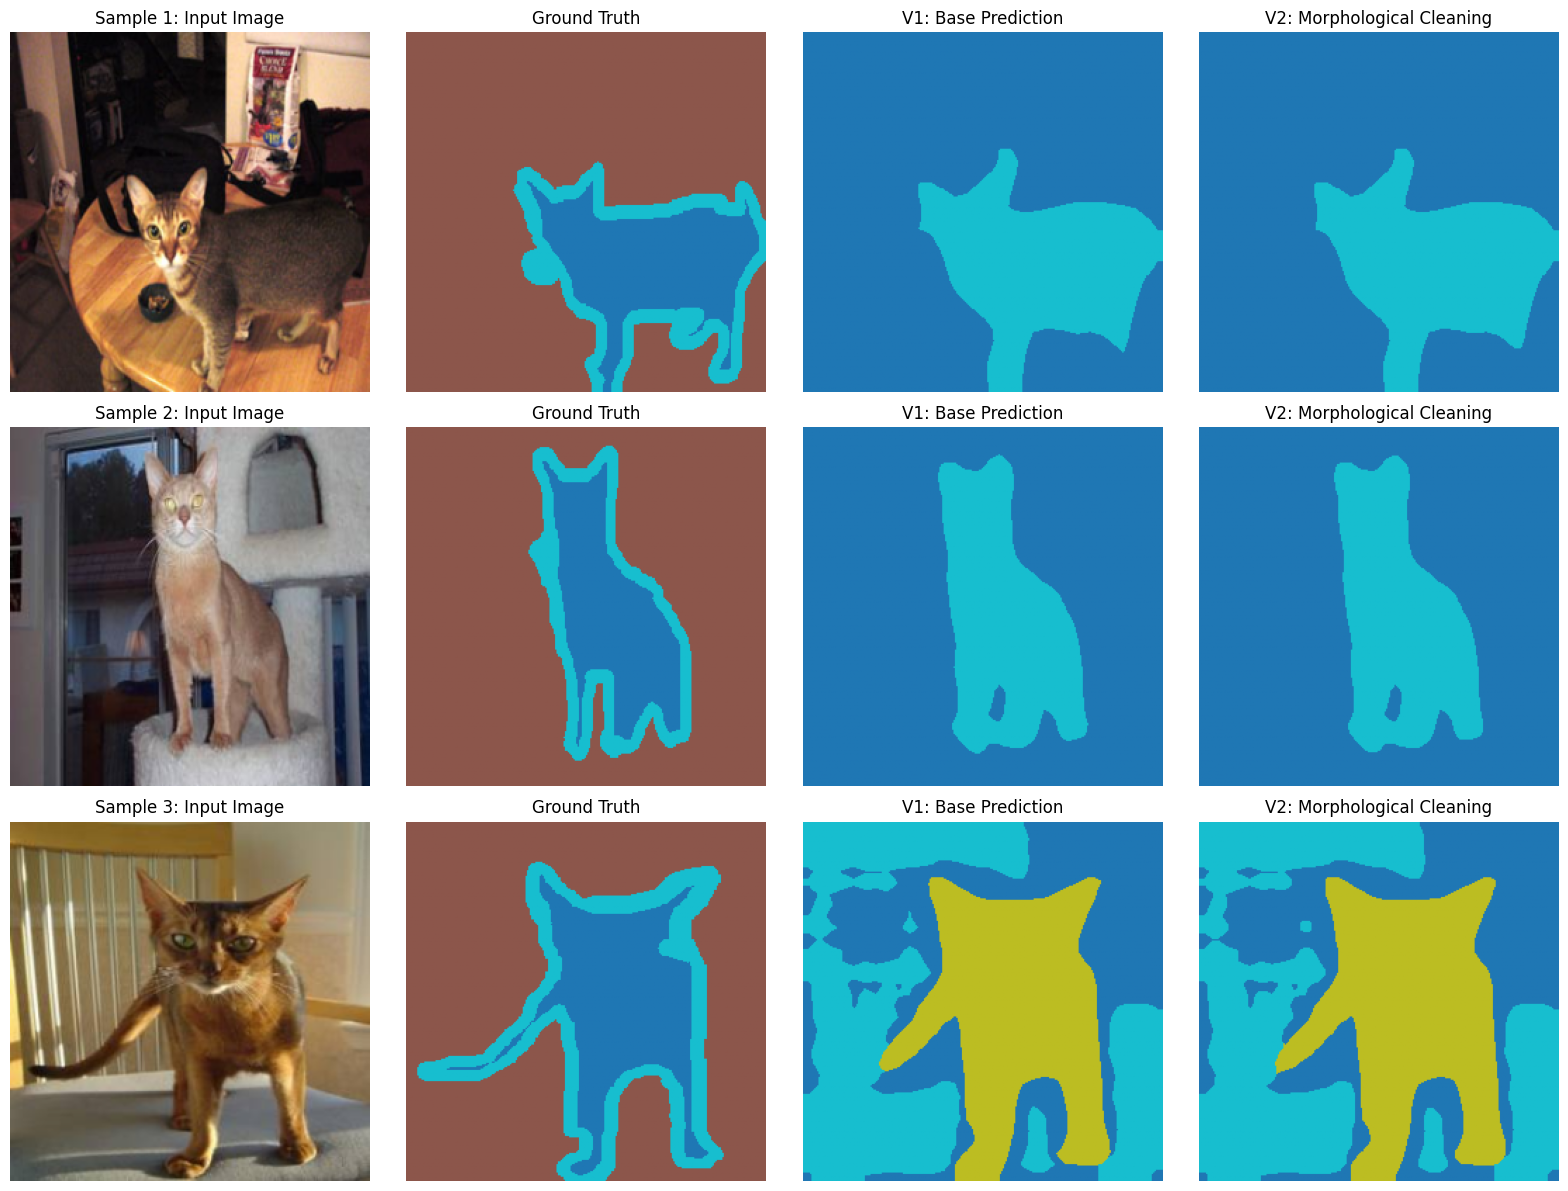

V1 Mean IoU: 0.6667
V2 Mean IoU: 0.6667

Saved artifacts/runs.csv
  experiment_id            task        dataset  seed       model_summary optimizer     lr  epochs_trained best_val_accuracy test_accuracy precision recall mean_iou                                            notes
0            C1  classification       CIFAR100    42           SimpleCNN      Adam  0.001              10             40.81          6.94                                                            No Augmentation
1            C2  classification       CIFAR100    42           SimpleCNN      Adam  0.001              10              43.0          8.38                                                          With Augmentation
2            C3  classification       CIFAR100    42              ResNet      Adam  0.001              10             25.93         26.21                                                   ResNet18 Frozen Backbone
3            C4  classification       CIFAR100    42              ResNet      Adam

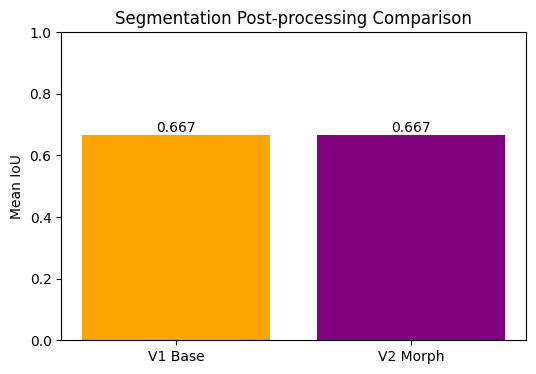

In [5]:
from torchvision.datasets import OxfordIIITPet

# Transforms for Segmentation
input_size = (256, 256)

img_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

target_transform = transforms.Compose([
    transforms.Resize(input_size, interpolation=Image.NEAREST),
    transforms.ToTensor()
])

# Load Dataset
pet_dataset = OxfordIIITPet(root='./data', split='test', target_types='segmentation',
                            transform=img_transform, target_transform=target_transform, download=True)

val_loader_pet = DataLoader(pet_dataset, batch_size=4, shuffle=False, num_workers=0)

# Load Model
model_seg = torchvision.models.segmentation.deeplabv3_resnet50(pretrained=True)

model_seg = model_seg.to(device)
model_seg.eval()

FOREGROUND_CLASS = 1
print(f"Foreground class for segmentation: {FOREGROUND_CLASS} (animal)")

# Helper for Segmentation Metrics
def calculate_iou(pred_mask, target_mask, num_classes=3):
    ious = []
    for cls in range(num_classes):
        pred_cls = (pred_mask == cls)
        target_cls = (target_mask == cls)
        intersection = (pred_cls & target_cls).sum().item()
        union = (pred_cls | target_cls).sum().item()
        if union == 0:
            iou = 1.0
        else:
            iou = intersection / union
        ious.append(iou)
    return np.mean(ious)

def calculate_foreground_iou(pred_mask, target_mask, fg_class=FOREGROUND_CLASS):

    pred_cls = (pred_mask == fg_class)
    target_cls = (target_mask == fg_class)
    intersection = (pred_cls & target_cls).sum().item()
    union = (pred_cls | target_cls).sum().item()
    if union == 0:
        return 1.0
    return intersection / union

def visualize_segmentation_combined(images, targets, preds_v1, preds_v2, save_path="artifacts/figures/segmentation_examples.png"):
    if isinstance(images, list):
        images = torch.stack(images)
    if isinstance(targets, list):
        targets = torch.stack(targets)
    if isinstance(preds_v1, list):
        preds_v1 = torch.stack(preds_v1)
    if isinstance(preds_v2, list):
        preds_v2 = torch.stack(preds_v2)

    if images is None or targets is None:
        print("Error: No valid images or targets for visualization")
        return

    n_samples = min(3, images.shape[0])

    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4*n_samples))

    if n_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(n_samples):
        img = images[i].cpu().permute(1, 2, 0).numpy()
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)

        target_np = targets[i].cpu().numpy()
        if target_np.ndim == 3:
            target_np = target_np[0]

        pred_v1_np = preds_v1[i].cpu().numpy()
        pred_v2_np = preds_v2[i].cpu().numpy()

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Sample {i+1}: Input Image")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(target_np, cmap='tab10')
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis('off')

        axes[i, 2].imshow(pred_v1_np, cmap='tab10')
        axes[i, 2].set_title("V1: Base Prediction")
        axes[i, 2].axis('off')

        axes[i, 3].imshow(pred_v2_np, cmap='tab10')
        axes[i, 3].set_title("V2: Morphological Cleaning")
        axes[i, 3].axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return fig

print("\nRunning V1 (Base Segmentation)...")
v1_ious = []
v2_ious = []
images_store = None
targets_store = None
v1_preds_store = None
v2_preds_store = None

with torch.no_grad():
    for i, batch in enumerate(val_loader_pet):
        if i >= 5:
            break

        if isinstance(batch, (list, tuple)) and len(batch) >= 2:
            images = batch[0]
            targets = batch[1]
        else:
            print(f"Unexpected batch format: {type(batch)}")
            continue

        images = images.to(device)

        if isinstance(targets, dict):
            masks = targets['mask'].to(device)
        elif isinstance(targets, torch.Tensor):
            masks = targets.to(device)
        else:
            print(f"Unexpected target format: {type(targets)}")
            continue

        if masks.dim() == 4:
            masks = masks.squeeze(1)

        outputs = model_seg(images)['out']
        preds = outputs.argmax(dim=1)

        if images_store is None:
            images_store = images.cpu().clone()
            targets_store = masks.cpu().clone()
            v1_preds_store = preds.cpu().clone()

        for j in range(images.size(0)):
            v1_ious.append(calculate_iou(preds[j], masks[j]))

        # --- V2: Morphological Post-processing ---
        preds_np = preds.cpu().numpy().astype(np.uint8)
        kernel = np.ones((3,3),np.uint8)

        processed_preds = []
        for j in range(preds_np.shape[0]):
            cleaned = cv2.morphologyEx(preds_np[j], cv2.MORPH_OPEN, kernel, iterations=2)
            processed_preds.append(torch.from_numpy(cleaned))

        processed_preds = torch.stack(processed_preds)

        if v2_preds_store is None:
            v2_preds_store = processed_preds.cpu().clone()

        for j in range(images.size(0)):
            v2_ious.append(calculate_iou(processed_preds[j].to(device), masks[j]))

# Save combined visualization
if images_store is not None:
    visualize_segmentation_combined(images_store, targets_store, v1_preds_store, v2_preds_store,
                                    save_path="artifacts/figures/segmentation_examples.png")
else:
    print("Warning: No images stored for visualization!")

v1_mean_iou = np.mean(v1_ious) if v1_ious else 0
v2_mean_iou = np.mean(v2_ious) if v2_ious else 0

print(f"V1 Mean IoU: {v1_mean_iou:.4f}")
print(f"V2 Mean IoU: {v2_mean_iou:.4f}")

# Add Part B results to CSV data
results.append({
    "experiment_id": "V1",
    "task": "segmentation",
    "dataset": "OxfordIIITPet",
    "seed": SEED,
    "model_summary": "DeepLabV3_ResNet50",
    "optimizer": "N/A",
    "lr": 0,
    "epochs_trained": 0,
    "best_val_accuracy": "",
    "test_accuracy": "",
    "precision": "",
    "recall": "",
    "mean_iou": round(v1_mean_iou, 4),
    "notes": f"Base Inference, Foreground class={FOREGROUND_CLASS}"
})

results.append({
    "experiment_id": "V2",
    "task": "segmentation",
    "dataset": "OxfordIIITPet",
    "seed": SEED,
    "model_summary": "DeepLabV3_ResNet50",
    "optimizer": "N/A",
    "lr": 0,
    "epochs_trained": 0,
    "best_val_accuracy": "",
    "test_accuracy": "",
    "precision": "",
    "recall": "",
    "mean_iou": round(v2_mean_iou, 4),
    "notes": f"Morphological Opening (3x3), Foreground class={FOREGROUND_CLASS}"
})

# Save runs.csv
df = pd.DataFrame(results)
df.to_csv("artifacts/runs.csv", index=False)
print("\nSaved artifacts/runs.csv")
print(df.to_string())

# Segmentation Metrics Plot
plt.figure(figsize=(6, 4))
plt.bar(['V1 Base', 'V2 Morph'], [v1_mean_iou, v2_mean_iou], color=['orange', 'purple'])
plt.ylabel("Mean IoU")
plt.title("Segmentation Post-processing Comparison")
plt.ylim(0, 1)
for i, v in enumerate([v1_mean_iou, v2_mean_iou]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
plt.savefig("artifacts/figures/segmentation_metrics.png")
plt.show()